## Цели и задачи проекта

В данном проекте стоит цель: провести A/B-тест на основе данных пользователей книжного приложения, чтобы проверить гипотезу о том, что жители Санкт-Петербурга проводят больше времени читая/слушая книги, чем пользователи из Москвы. Для достижении цели стоят следующие задачи: знакомство и обработка исходных данных, подготовка к тесту, выбор статистического критерия, проведение и анализ теста

## Описание данных

Данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности:

- city — город пользователя;
- puid — идентификатор пользователя;
- hours — общее количество часов активности 

## Содержимое проекта

1. Загрузка данных и предварительный анализ
2. Предобработка данных (дубликаты, пропуски)
3. Проверка групп на независимость
4. Сравнение размера групп, их статистик и распределений
5. Выбор статистического критерия
6. Проведение теста и анализ результатов

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


Проверим на дубликаты и пропуски

In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

city     0
puid     0
hours    0
dtype: int64

Нет дубликатов и пропусков

Нужно убедиться, что группы независимы.

Для этого проверим наличие пользователей, которые оказались пользователями из Москвы и Петербурга. Уберем таких пользователей из эксперимента

In [8]:
users_city_count = df.groupby('puid')['city'].nunique()

dupl_cities = users_city_count[users_city_count > 1]

display(f"Количество пересекающихся пользователей: {len(dupl_cities)}")

'Количество пересекающихся пользователей: 244'

In [9]:
unique_city_users = users_city_count[users_city_count == 1].index

df_clean = df[df['puid'].isin(unique_city_users)]

display(f"Удалено пользователей: {len(dupl_cities)}")
display(f"Осталось: {df_clean['puid'].nunique()}")

'Удалено пользователей: 244'

'Осталось: 8296'

Сравним размеры групп, их статистики и распределение

In [10]:
stats_df = df_clean.groupby('city')['hours'].agg(['count', 'mean', 'median', 'std', 'var'])
stats_df

,count,mean,median,std,var
city,,,,,
Москва,5990,10.848192,0.888232,36.925622,1363.501557
Санкт-Петербург,2306,11.264433,0.875355,39.831755,1586.568674


Большое стандартное отклонение, среднее завышено относительно медианы. Значит, в данных много выбросов и аномально высоких значений. Медиана низикая за счет пользователей, открывших и почти сразу закрывших приложение. Медианы почти совпадают, дисперсии между городами отличаются.

Средние тоже отличаются, далее но с помощью теста проверим, случайность это или нет.

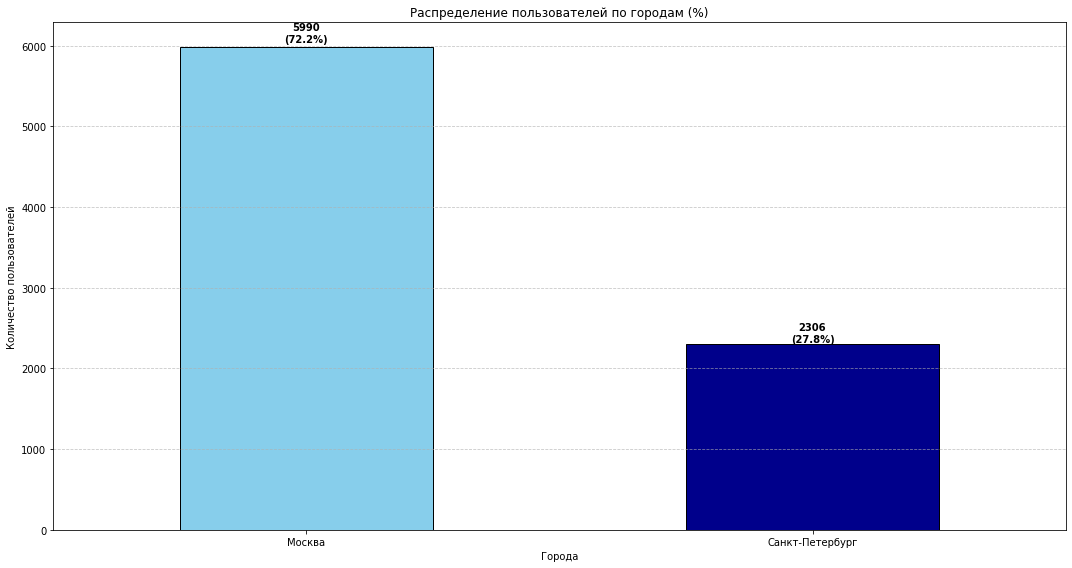

In [11]:
plt.figure(figsize=(15, 8))

users_by_city = df_clean.groupby('city')['puid'].count()
total_users = users_by_city.sum()
percents = (users_by_city / total_users) * 100

users_by_city.plot(kind='bar', color=['skyblue', 'darkblue'], edgecolor='black')

plt.title('Распределение пользователей по городам (%)')
plt.xlabel('Города')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (v, p) in enumerate(zip(users_by_city, percents)):
    plt.text(i, v + (v * 0.01), f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Размеры выборок сильно отличаются. 

Наша рассматриваемая метрика в эксперименте - среднее время пользования

Из того, что сравниваем средние значения в эксперименте, а также на основе полученного предварительного анализа данных, выберем Т-тест Уэлча как статистический.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
moscow_hours = df_clean[df_clean['city'] == 'Москва']['hours']
spb_hours = df_clean[df_clean['city'] == 'Санкт-Петербург']['hours']

alpha = 0.05

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
   moscow_hours,
   spb_hours,
    equal_var=False,
    alternative = 'less'
)
if p_value_welch_ttest > alpha:
    display(f'pvalue={p_value_welch_ttest:.3f} > {alpha}')
    display('Нулевая гипотеза находит подтверждение: средняя активность по времени в Москве и Петербурге не различаются.')
else:
    display(f'pvalue={p_value_welch_ttest:.3f} < {alpha}')
    display('Нулевая гипотеза не находит подтверждения: средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо')

'pvalue=0.332 > 0.05'

'Нулевая гипотеза находит подтверждение: средняя активность по времени в Москве и Петербурге не различаются.'

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



После загрузки, обработки и анализа исходных данных были выбраны

- Т-тест Уэлча (из-за разницы в размере выборкок и дисперсий)
- уровень значимости 0.05 (стандартный)

В результате проведенного теста получили p-value = 0.332. Он значительно превышает выбранный уровень значимости 0.05: недостаточно оснований отклонить нулевую гипотезу.

Статистически значимых различий в среднем времени чтения/слушания книг между жителями Москвы и Санкт-Петербурга не обнаружено. Разница средних значений случайна.

Почему так происходит? Медианное время в обоих городах почти совпадает, значит, поведение среднестатистического пользователя в двух городах совпадает, а среднее же значение различается из-за пользователей с рекордными часами чтения/слушания.

----